# MSBA 265 - Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audit

**Author:** Visiting Instructor Shyla Solis
**Course:** MSBA 265 - Business Analytics Topics
**Dataset:** French Motor Third Party Liability Claims (OpenML ID: 42124)

---

### Business Problem Overview
In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or assessing business strategy dashboards, we must inspect raw feature data types, construct a domain-specific Business Data Dictionary, plot feature distributions, and evaluate univariate skewness and visually diagnose extreme outliers.

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

df = pd.read_csv(data_path)
print(f"[+] Loaded Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Render interactive HTML table head
df.head(10)

[+] Loaded Dataset Shape: 678,013 rows x 12 columns


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [11]:
print("================================================")
print("        1. STRUCTURAL DATA TYPES & NULLS")
print("================================================")
df.info()

print("\n================================================")
print("        2. SUMMARY STATISTICS (NUMERICAL)")
print("================================================")
df.describe().T

        1. STRUCTURAL DATA TYPES & NULLS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  object 
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  object 
 9   VehGas      678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB

        2. SUMMARY STATISTICS (NUMERICAL)


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [12]:
# Part 2.2 - Raw Boundary Audit

audit_cols = ["DrivAge", "Exposure", "BonusMalus"]

print("Minimum values:")
print(df[audit_cols].min())

print("\nMaximum values:")
print(df[audit_cols].max())

print("\nMissing values:")
print(df[audit_cols].isna().sum())

print("\nNegative DrivAge values:")
print((df["DrivAge"] < 0).sum())

print("\nZero DrivAge values:")
print((df["DrivAge"] == 0).sum())

Minimum values:
DrivAge       18.000000
Exposure       0.002732
BonusMalus    50.000000
dtype: float64

Maximum values:
DrivAge       100.00
Exposure        2.01
BonusMalus    230.00
dtype: float64

Missing values:
DrivAge       0
Exposure      0
BonusMalus    0
dtype: int64

Negative DrivAge values:
0

Zero DrivAge values:
0


In [13]:
business_definitions = {
    "IDpol": ("Policy ID", "Key ID", "Unique policy identification key assigned to contract."),
    "ClaimNb": ("Claim Count", "Count", "Total insurance claims filed during policy coverage period."),
    "Exposure": ("Risk Exposure", "Years (0.0-1.0)", "Fraction of year policy was active (e.g., 0.50 = 6 months coverage)."),
    "Area": ("Area Risk Code", "Ordinal Category", "Geographic risk code of policyholder address (A = rural, F = urban)."),
    "VehPower": ("Engine Power", "Tax HP", "Fiscal power rating category of vehicle engine."),
    "VehAge": ("Vehicle Age", "Years", "Age of the insured vehicle in years."),
    "DrivAge": ("Driver Age", "Years", "Age of the primary insured driver in years."),
    "BonusMalus": ("Claim History Index", "Index Score (50-350)", "Regulatory driver risk score (< 100: safe discount; > 100: claim surcharge)."),
    "VehBrand": ("Brand Class", "Category Code", "Anonymized vehicle manufacturer/brand classification code."),
    "VehGas": ("Fuel Type", "Binary Class", "Engine fuel type used (Diesel vs. Regular/Gasoline)."),
    "Density": ("Population Density", "People / km2", "Population density of policyholder’s municipality."),
    "Region": ("Administrative Region", "Region Code", "French administrative region code corresponding to residency location.")
}

dict_list = []

for col in df.columns:
    label, unit, definition = business_definitions.get(
        col, (col, "N/A", "No business definition provided.")
    )
    
    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
    })

dict_df = pd.DataFrame(dict_list)

display(dict_df)

reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

dict_path = os.path.join(reports_dir, "data_dictionary.csv")

dict_df.to_csv(dict_path, index=False)

print(f"\n[+] Successfully exported Business Data Dictionary artifact to: {dict_path}")

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0-1.0),0,181,"Fraction of year policy was active (e.g., 0.50..."
3,Area,Area Risk Code,object,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of vehicle engine.
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years.
6,DrivAge,Driver Age,int64,Years,0,83,Age of the primary insured driver in years.
7,BonusMalus,Claim History Index,int64,Index Score (50-350),0,115,Regulatory driver risk score (< 100: safe disc...
8,VehBrand,Brand Class,object,Category Code,0,11,Anonymized vehicle manufacturer/brand classifi...
9,VehGas,Fuel Type,object,Binary Class,0,2,Engine fuel type used (Diesel vs. Regular/Gaso...



[+] Successfully exported Business Data Dictionary artifact to: ../reports/data_dictionary.csv


Part 2.4 – Modeling Defense

Exposure acts as a rate offset because it represents the fraction of a year that an insurance policy was active, so it adjusts the expected number of claims for the amount of time the policy was exposed to risk. Density is a continuous numerical variable because it measures population density in people per square kilometer and can take many numerical values. Area is a categorical variable because it represents geographic risk categories rather than a continuous numerical measurement. Density and Area should not both be included in a linear regression model in their current forms because Area represents geographic groupings while Density captures a continuous geographic characteristic, creating overlapping information about location and potentially introducing redundancy or multicollinearity into the model.

In [14]:
print("================================================")
print("        UNIVARIATE SKEWNESS DIAGNOSTICS        ")
print("================================================")

numeric_df = df.select_dtypes(include=[np.number])
skewness_series = numeric_df.skew().sort_values(ascending=False)

skew_summary = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness Coefficient": skewness_series.values,
    "Diagnosis": ["Extremely Right-Skewed" if s > 3.0 else "Moderately Skewed" if abs(s) > 1.0 else "Unskewed / Symmetric" for s in skewness_series.values],
    "Action Required": ["Log / Box-Cox Transform" if abs(s) > 1.0 else "Standard Scaler Sufficient" for s in skewness_series.values]
})

display(skew_summary)

        UNIVARIATE SKEWNESS DIAGNOSTICS        


,Feature,Skewness Coefficient,Diagnosis,Action Required
0,ClaimNb,5.599613,Extremely Right-Skewed,Log / Box-Cox Transform
1,Density,4.651421,Extremely Right-Skewed,Log / Box-Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box-Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box-Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box-Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,Standard Scaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,Standard Scaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,Standard Scaler Sufficient


In [15]:
print("================================================")
print("        PEARSON MULTICOLLINEARITY AUDIT        ")
print("================================================")

corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_tri.columns:
    high_corr_features = upper_tri.index[upper_tri[col] >= 0.85].tolist()
    
    for feat in high_corr_features:
        val = upper_tri.loc[feat, col]
        high_corr_pairs.append({
            "Feature 1": feat,
            "Feature 2": col,
            "Pearson Correlation (|r|)": round(val, 4),
            "Status": "ACTION REQUIRED: Severe Multicollinearity"
        })

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.")

        PEARSON MULTICOLLINEARITY AUDIT        
[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.


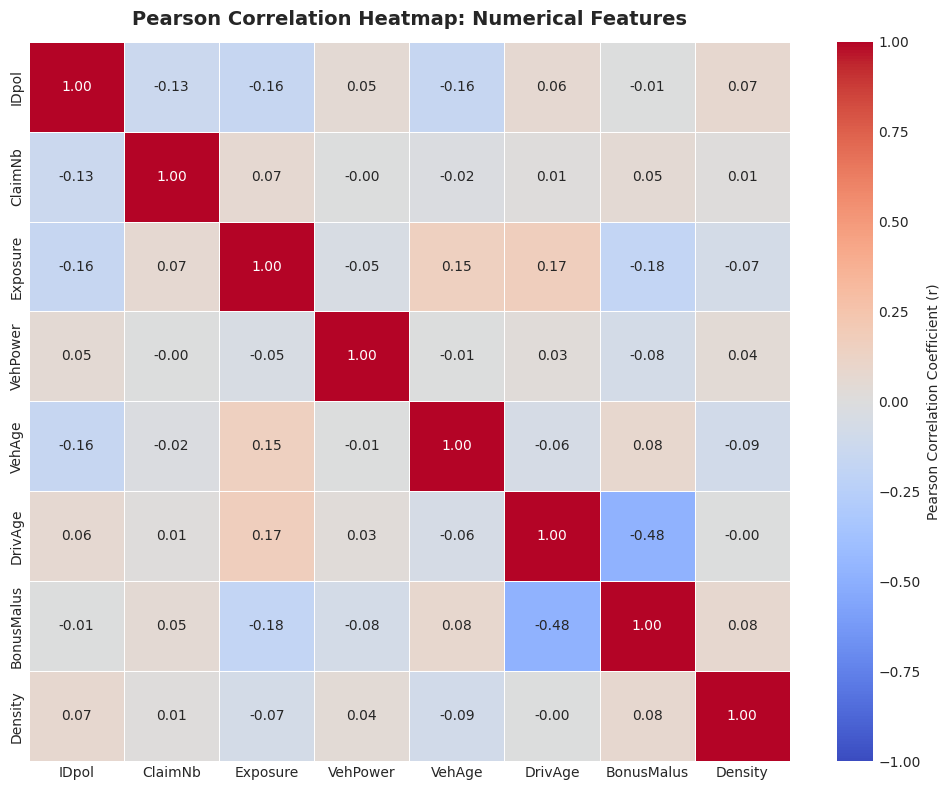

[+] Saved correlation heatmap graphics artifact to: ../reports/figures/correlation_heatmap.png


In [16]:
# Cell 6b: Render and Export Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))

# Compute Pearson correlation matrix across numerical variables
corr = numeric_df.corr()

# Generate a diverging color map
# Blue = Negative, Red = Positive
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)

plt.title(
    "Pearson Correlation Heatmap: Numerical Features",
    fontsize=14,
    fontweight="bold",
    pad=12
)
plt.tight_layout()

heatmap_path = os.path.join(
    "..", "reports", "figures", "correlation_heatmap.png"
)
plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"[+] Saved correlation heatmap graphics artifact to: {heatmap_path}")

Executive Interpretation Statements

1. Baseline Observation
- Visual Observation: Most variables show weak correlations. The correlation values range from r = −0.48 to r = +0.17.
- Key Finding: Most relationships are close to zero, showing limited linear relationships between the variables.
- Recommended Action: These variables can be reviewed individually when building future models.

 2. Key Feature Relationship
- Feature Relationship: DriverAge and BonusMalus have a moderate negative correlation (r = −0.48).
- Interpretation: As DriverAge increases, BonusMalus generally decreases in this dataset.
- Recommended Action: This relationship should be examined further during later analysis and modeling.

 3. If-Then: High Collinearity
- Scenario: If two predictors had a very strong correlation (r ≥ +0.85), we would check for multicollinearity.
- Key Metric: A high correlation between predictors could create problems in a regression model.
- Recommended Action: We would use VIF to help decide whether a variable should be removed.

4. If-Then: Non-Linear Relationship
- Scenario: A correlation near r = 0 does not mean there is no relationship.
- Key Finding: A curved or U-shaped pattern may have a low Pearson correlation even when a relationship exists.
- Recommended Action: We would use scatter plots or other methods to check for non-linear relationships.

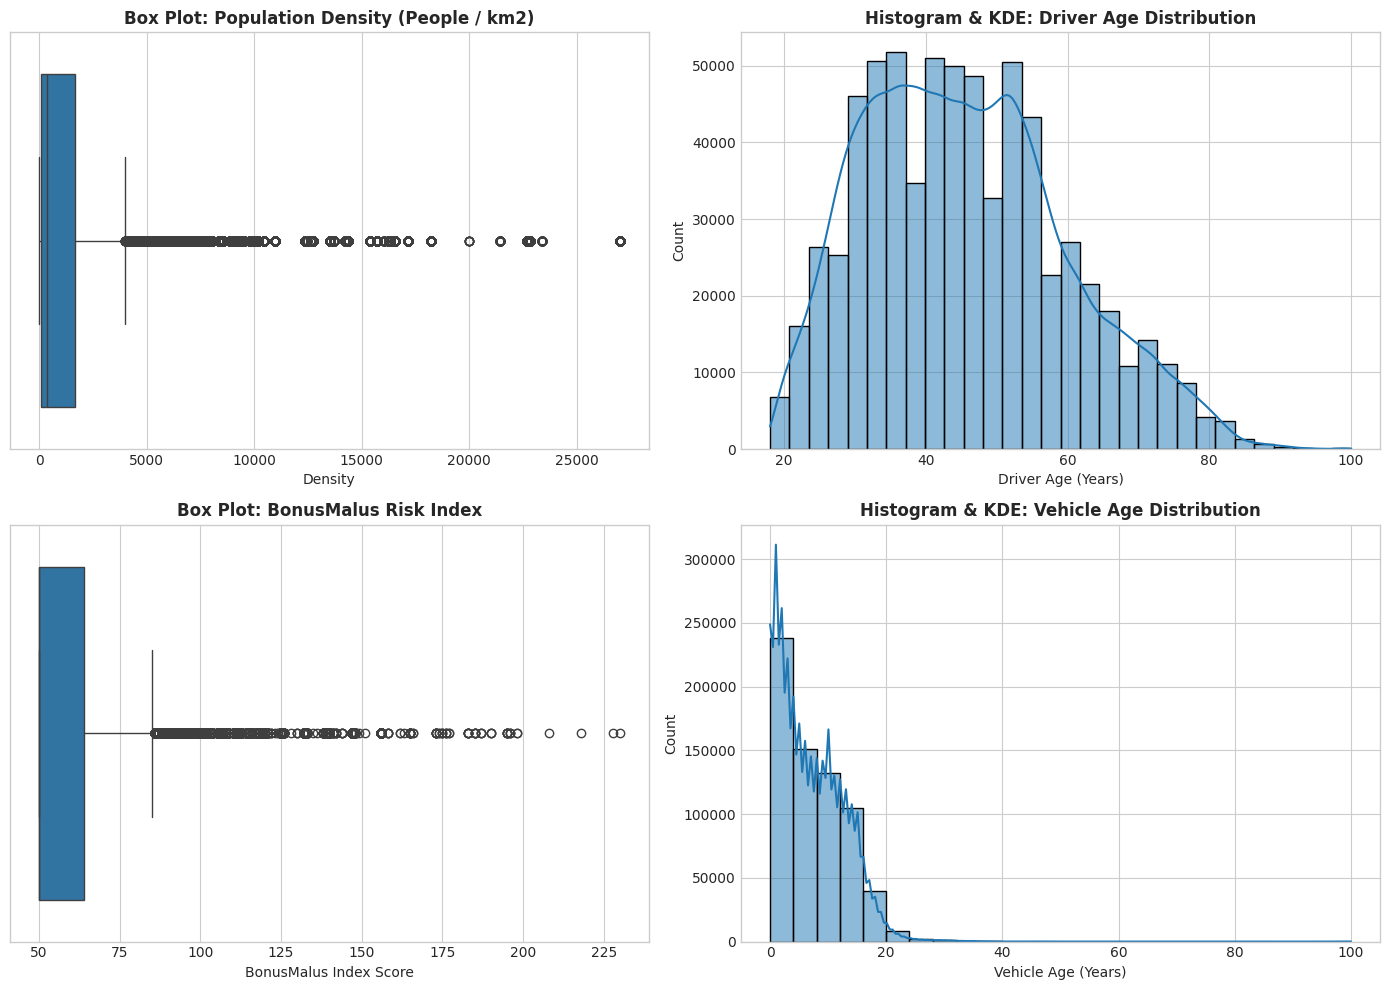

[+] Saved distribution graphics artifact to: ../reports/figures/feature_distributions.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Population Density
sns.boxplot(x=df['Density'], ax=axes[0,0])
axes[0,0].set_title('Box Plot: Population Density (People / km2)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Density')

# Driver Age
sns.histplot(df['DrivAge'], kde=True, ax=axes[0,1], bins=30)
axes[0,1].set_title('Histogram & KDE: Driver Age Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Driver Age (Years)')

# BonusMalus
sns.boxplot(x=df['BonusMalus'], ax=axes[1,0])
axes[1,0].set_title('Box Plot: BonusMalus Risk Index', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('BonusMalus Index Score')

# Vehicle Age
sns.histplot(df['VehAge'], kde=True, ax=axes[1,1], bins=25)
axes[1,1].set_title('Histogram & KDE: Vehicle Age Distribution', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Vehicle Age (Years)')

plt.tight_layout()

fig_path = os.path.join("..", "reports", "figures", "feature_distributions.png")

plt.savefig(fig_path, dpi=300)
plt.show()

print(f"[+] Saved distribution graphics artifact to: {fig_path}")

Distribution Interpretation Statements

1. Population Density
- Distribution Shape: Population Density is strongly right-skewed, with most observations at lower values and a long tail toward higher values.
- Key Metrics/Outliers: The box plot shows many high-value outliers, with some observations above 20,000 people/km².
- Recommended Action: Because of the extreme values, we should use robust statistics and consider a log transformation when modeling Density.

2. Driver Age
- Distribution Shape: DriverAge is mostly concentrated between about 25 and 60 years, with fewer observations at older ages.
- Key Metrics: The highest concentration is around the 30–55 year range, with fewer very young and very old drivers.
- Recommended Action: DriverAge can be used as a numeric predictor, but we should check for non-linear patterns before modeling.

 3. BonusMalus
- Distribution Shape: BonusMalus is strongly right-skewed, with most values concentrated at the lower end and a long tail toward higher scores.
- Key Metrics/Outliers: Most values are around 50–65, while many high-value outliers extend above 100 and reach over 200.
- Recommended Action: We should investigate the extreme values and consider robust methods or transformations during modeling.

4. Vehicle Age
- Distribution Shape: VehicleAge is strongly right-skewed, with most vehicles having a relatively low age and fewer older vehicles.
- Key Metrics: Most observations are concentrated between about 0 and 15 years, with a long tail extending to older vehicles.
- Recommended Action: We should check for non-linear effects of VehicleAge and consider a transformation if needed.